# Custom algorithm approach

This notebook explores the use of an altenative algorithm to generate ontologies based on the conclusion from naive approach.

We will explore the definition of comunities.

In [24]:
## Libraries
import sys
from pathlib import Path
import pandas as pd
import json
import chromadb
import math
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))
from src.services import ChatGpt


In [25]:
## Setup parameters

domain = "Star Trek"
initial_term_seed = 20
ucb1_exploration_constant = 2
k_similarity_treshold = 20
g_min_reward_treshold = 10
max_iterations = 10


----
## Step 1: generate seeds and embedding

We will request an initial n seed terms and their short description and embedd the result. We use chroma as vector store to keep it efficient.

In [26]:
agent = ChatGpt()
agent.model = "gpt-4o-mini"
chroma_client = chromadb.Client()
collection = chroma_client.get_or_create_collection(name="ontology")

In [27]:
terms_list_str = agent.chat(
    instructions="You are a taxonomy and ontology expert. Provide concise and accurate responses based on the user's queries.",
    input=f"""
        Provide a list of {initial_term_seed} categories, terms or words closely related to domain or topic and using the provided terms as reference.
        
        - the domain or topic is: {domain}
        
        Your output should be a json array with only the category names, with a small text describing the term and relation to theme. 
        This categories should include the given terms and be closely related to the domain or topic.
        Do not encapsulate the output in code blocks.
        
        Example output:
        [
            "category1": "small description1",
            "category2": "small description12",
            ...            "category100":"small description100"
        ]
        
    """
)

In [28]:
terms_list_json = json.loads(terms_list_str)
terms_list_flat = [(list(d.keys())[0], list(d.values())[0]) for d in terms_list_json]
terms_list_df = pd.DataFrame(terms_list_flat, columns=["term", "description"])
print(terms_list_df.head(10))
print(terms_list_df.tail(10))

          term                                        description
0    Starfleet  The deep space exploratory and defense organiz...
1   Federation  The interstellar alliance of planets and speci...
2     Klingons  A warrior species known for their honor and co...
3         Borg  A cybernetic collective bent on assimilating o...
4   Warp Drive  The faster-than-light propulsion system that e...
5      Phasers  Energy-based weapons commonly used by Starflee...
6  Transporter  A device that instantaneously transports indiv...
7     Holodeck  A simulated reality space used for recreation ...
8     Romulans  A secretive and strategic species known for th...
9      Vulcans  A highly logical species renowned for their la...
                   term                                        description
11           Red Shirts  A colloquial term for Starfleet personnel who ...
12          Q Continuum  A race of omnipotent beings often manipulating...
13  Starship Enterprise  The iconic starship know

In [29]:
documents = [f"{row['term']}: {row['description']}" for _, row in terms_list_df.iterrows()]
ids = [f"term_{i}" for i in range(len(terms_list_df))]

collection.add(
    documents=documents,
    ids=ids
)

----
## Step 2: Generate Semantic Similarity Graph and detect initial communities

In [30]:
import networkx as nx
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Retrieve embeddings and terms from Chroma
results = collection.get(ids=ids, include=['embeddings', 'documents'])
embeddings = np.array(results['embeddings'])
terms = [doc.split(":")[0] for doc in results['documents']]  # Extract term from "term: description"

def build_similarity_graph(terms, embeddings, threshold=0.7):
    G = nx.Graph()
    for term in terms:
        G.add_node(term)
    sim = cosine_similarity(embeddings)
    n = len(terms)
    for i in range(n):
        for j in range(i + 1, n):
            if sim[i, j] >= threshold:
                G.add_edge(
                    terms[i],
                    terms[j],
                    weight=float(sim[i, j])
                )
    return G

# Build the graph
G = build_similarity_graph(terms, embeddings, threshold=0.5)

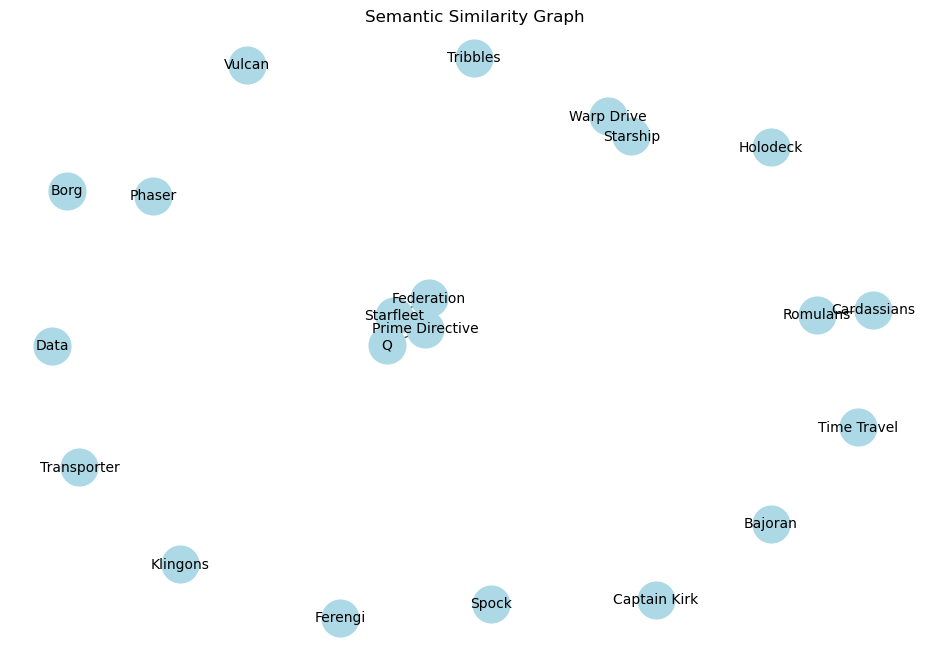

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42) 
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue')
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.7)
nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif")
plt.title("Semantic Similarity Graph")
plt.axis('off')
plt.show()

In [32]:
sim = cosine_similarity(embeddings)
print("Max similarity (excluding self):", np.max(sim - np.eye(len(sim))))
print("Min similarity:", np.min(sim))

Max similarity (excluding self): 0.6830289203234758
Min similarity: -0.02946526419434539


In [33]:
import community as community_louvain

# Compute the best partition
partition = community_louvain.best_partition(G, weight='weight')

# Print communities
for community_id in set(partition.values()):
    members = [node for node, cid in partition.items() if cid == community_id]
    print(f"Community {community_id}: {members}")

Community 0: ['Vulcan']
Community 1: ['Starfleet', 'Federation', 'Q', 'Prime Directive']
Community 2: ['Klingons']
Community 3: ['Borg']
Community 4: ['Holodeck']
Community 5: ['Ferengi']
Community 6: ['Warp Drive', 'Starship']
Community 7: ['Transporter']
Community 8: ['Phaser']
Community 9: ['Spock']
Community 10: ['Captain Kirk']
Community 11: ['Romulans', 'Cardassians']
Community 12: ['Tribbles']
Community 13: ['Data']
Community 14: ['Time Travel']
Community 15: ['Bajoran']


---
## 3. Induce initial ontology

In [ ]:
def induce_local_ontology(partition, terms_list_df, agent):
    # Group terms by community
    communities = {}
    for term, cid in partition.items():
        communities.setdefault(cid, []).append(term)

    results = {}

    for cid, terms in communities.items():
        # Fetch descriptions
        descs = []
        for term in terms:
            desc = terms_list_df.loc[terms_list_df['term'] == term, 'description'].values
            if len(desc) > 0:
                descs.append(f"- {term}: {desc[0]}")
            else:
                descs.append(f"- {term}: [No description found]")

        prompt = f"""
        Given the list of terms below, evaluate each pair of terms and classify the relationship between them as 'similarity', 'composition', or 'no relation'.

        List of terms:
        {chr(10).join(descs)}

        For each pair (source, target), indicate:
        - 'similarity' if the terms are similar or belong to the same group/concept.
        - 'composition' if one term is part of the other (e.g., component, subclass, instance).
        - 'no relation' if no meaningful relationship exists between the terms.

        Additionally, provide:
        - A confidence score (0-100%) for the classification.
        - A justification for the classification.

        Output JSON:
        [
            {{
                "source": "term1",
                "target": "term2",
                "relation": "similarity | composition | no relation",
                "confidence": 95.0,
                "justification": "Explanation of the classification"
            }},
            ...
        ]
        Only include pairs with a confidence of at least 5%. Do not invent new terms. Do not explain, just classify.
        """
        response = agent.chat(
            instructions="Classify relationships between pairs of terms.",
            input=prompt
        )
        try:
            relations = json.loads(response)
            # Filter out pairs with confidence below 97% or with "no relation"
            filtered_relations = [
                rel for rel in relations
                if rel.get("confidence", 0) >= 5 and rel.get("relation") != "no relation"
            ]
            results[cid] = filtered_relations
        except Exception:
            results[cid] = []  # fallback: empty list if parsing fails

    return results

In [38]:
# Usage:
local_ontologies = induce_local_ontology(partition, terms_list_df, agent)
print(json.dumps(local_ontologies, indent=2))

{
  "1": [],
  "2": [],
  "3": [],
  "4": [],
  "6": [],
  "7": [],
  "8": [],
  "9": [],
  "10": [],
  "11": [],
  "12": [],
  "13": [],
  "15": [],
  "0": [],
  "5": [],
  "14": []
}


In [36]:
validated_rows = []
proposals = []

# Build the set of allowed terms (from your original terms)
allowed_terms = set(terms_list_df['term'])

for community_id, json_str in local_ontologies.items():
    # Remove code block markers if present
    json_str = json_str.strip('`json\n').strip('`\n')
    try:
        rels = json.loads(json_str)
        for rel in rels:
            rel['community'] = community_id
            if rel['source'] in allowed_terms and rel['target'] in allowed_terms:
                validated_rows.append(rel)
            else:
                proposals.append(rel)
    except Exception as e:
        print(f"Error parsing community {community_id}: {e}")

ontology_df = pd.DataFrame(validated_rows)
proposals_df = pd.DataFrame(proposals)

print("Ontology (closed-world, valid only):")
print(ontology_df)
print("\nProposals (invented or latent terms):")
print(proposals_df)

AttributeError: 'list' object has no attribute 'strip'

In [14]:
ontology_df = ontology_df.drop_duplicates(subset=['source', 'target'], keep='first')
ontology_df = ontology_df[ontology_df['source'] != ontology_df['target']]
ontology_df

,source,target,relation,community
0,Starfleet,Federation,similarity,1
1,Starfleet,Prime Directive,composition,1
2,Federation,Prime Directive,composition,1
3,Q,Starfleet,similarity,1
4,Q,Federation,similarity,1
5,Warp Drive,Starship,composition,5
6,Romulans,Cardassians,similarity,11


In [15]:
proposals_df


,source,target,relation,community
0,Spock,Vulcan logic,similarity,9
1,Spock,science officer,composition,9
2,Spock,mixed heritage,similarity,9
3,Vulcan,Home planet of the Vulcans,composition,0
4,Ferengi,capitalism,similarity,6
5,Ferengi,profit,similarity,6
6,Ferengi,society,composition,6
7,Time Travel,Star Trek,similarity,14


In [16]:
import networkx as nx

# Create a directed graph for the ontology
ontology = nx.DiGraph()

# Add edges from the ontology_df DataFrame
for _, row in ontology_df.iterrows():
    ontology.add_edge(
        row['source'],
        row['target'],
        relation=row['relation'],
        justification=row['justification'],
        community=row['community']
    )

# Example: print all edges with data
for u, v, data in ontology.edges(data=True):
    print(f"{u} --[{data['relation']}]--> {v} | {data['justification']} (community {data['community']})")

KeyError: 'justification'

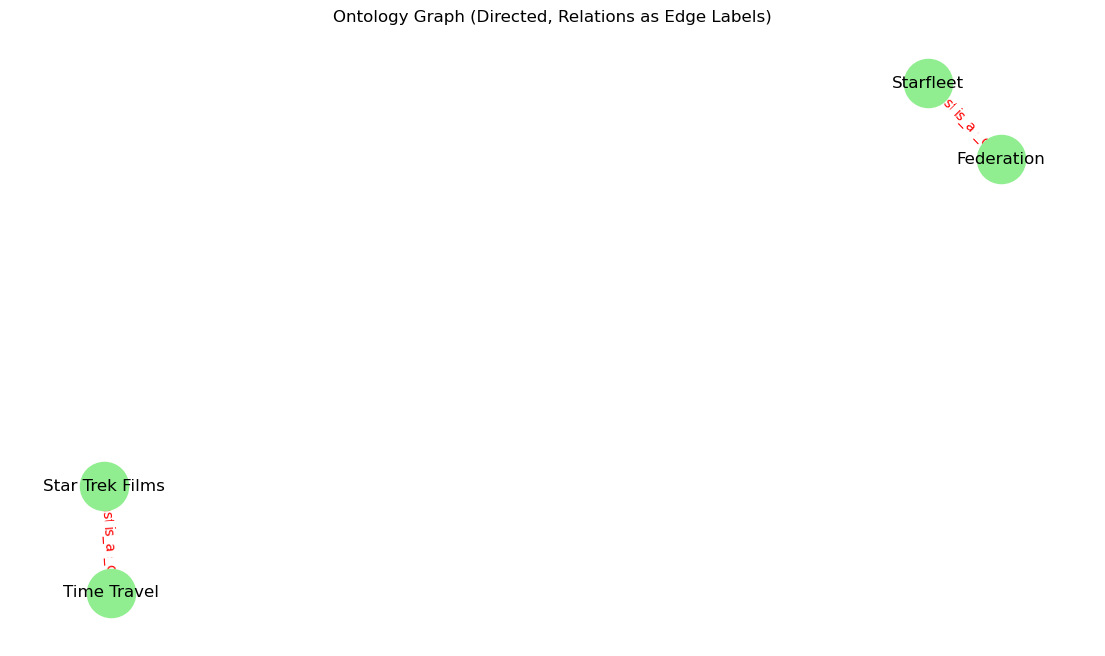

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
pos = nx.spring_layout(ontology, seed=42)

# Draw nodes
nx.draw_networkx_nodes(ontology, pos, node_size=1200, node_color='lightgreen')

# Draw directed edges
nx.draw_networkx_edges(ontology, pos, arrowstyle='->', arrowsize=20, edge_color='gray')

# Draw node labels
nx.draw_networkx_labels(ontology, pos, font_size=12, font_family="sans-serif")

# Draw edge labels (relation type)
edge_labels = {(u, v): d['relation'] for u, v, d in ontology.edges(data=True)}
nx.draw_networkx_edge_labels(ontology, pos, edge_labels=edge_labels, font_color='red', font_size=10)

plt.title("Ontology Graph (Directed, Relations as Edge Labels)")
plt.axis('off')
plt.show()

---
## 4. Decides to explore or exploit

In [17]:
import re
import json

def clean_and_parse_json(response_text):
    """
    Cleans LLM output to extract just the JSON part.
    Removes markdown backticks and whitespace.
    """
    # Remove ```json ... ``` or ``` ... ```
    cleaned = re.sub(r"```json", "", response_text)
    cleaned = re.sub(r"```", "", cleaned)
    cleaned = cleaned.strip()
    
    try:
        return json.loads(cleaned)
    except json.JSONDecodeError as e:
        print(f"JSON Parsing Error: {e}")
        print(f"Raw text was: {response_text[:100]}...") # Print start of text for debugging
        return None

In [18]:

class OntologyExpander:
    def __init__(self, G, ontology, partition, agent, exploration_constant=2.0):
        self.G = G
        self.ontology = ontology
        self.partition = partition
        self.agent = agent
        self.C = exploration_constant
        
        # Get unique community IDs
        self.community_ids = list(set(partition.values()))
        
        # State tracking for UCB1
        # n_j: number of times community j has been selected
        self.counts = {cid: 0 for cid in self.community_ids} 
        # x_j: average reward (new terms found) for community j
        self.values = {cid: 0.0 for cid in self.community_ids} 
        self.total_counts = 0
        
        # Convergence tracking
        self.history_rewards = []
    
    def select_community(self):
        """
        Uses UCB1 to select the next community to expand.
        """
        # If any community hasn't been tried, explore it first (Initialization)
        for cid in self.community_ids:
            if self.counts[cid] == 0:
                return cid

        best_score = -float('inf')
        best_community = None

        for cid in self.community_ids:
            # UCB1 Formula: Average Reward + C * sqrt(2 * ln(Total) / Times_Played)
            exploitation = self.values[cid]
            exploration = self.C * math.sqrt((2 * math.log(self.total_counts)) / self.counts[cid])
            score = exploitation + exploration
            
            if score > best_score:
                best_score = score
                best_community = cid
                
        return best_community

    def update_stats(self, community_id, reward):
        """
        Update the Bandit stats after an expansion attempt.
        """
        self.counts[community_id] += 1
        self.total_counts += 1
        
        # Update running average of rewards
        n = self.counts[community_id]
        current_val = self.values[community_id]
        # Iterative mean update
        self.values[community_id] = ((n - 1) / n) * current_val + (1 / n) * reward
        
        self.history_rewards.append(reward)

    def check_convergence(self, window=3, threshold=0.5):
        """
        Simple convergence check: 
        If the average reward over the last 'window' steps is below 'threshold', stop.
        """
        if len(self.history_rewards) < window:
            return True # Keep growing
        
        recent_avg = sum(self.history_rewards[-window:]) / window
        if recent_avg < threshold:
            print(f"--> System Converged. Recent average reward: {recent_avg}")
            return False # Stop growing
        
        return True

In [ ]:
def generate_and_validate_terms(expander, community_id, terms_df, chroma_collection):
    """
    Executes the growth cycle for a specific community.
    """
    # 1. Get current terms in this community to ground the prompt
    current_terms = [node for node, cid in expander.partition.items() if cid == community_id]
    
    if not current_terms:
        return 0

    print(f"\n--- Expanding Community {community_id} (Size: {len(current_terms)}) ---")
    print(f"Context terms: {current_terms[:5]}...")

    # 2. PROMPT: Generate new candidate terms
    generation_prompt = f"""
    You are an ontology expert in the domain: {domain}.
    
    Focus on this specific cluster of concepts:
    {', '.join(current_terms)}
    
    Task:
    Generate 5 NEW, SPECIFIC concepts that are missing from this cluster.
    These should be specific subclasses, instances, or closely related concepts.
    
    Constraints:
    1. Do NOT output terms that are already listed above.
    2. Output strictly raw JSON. No markdown code blocks.
    
    Output JSON format:
    [
        {{"term": "New Term 1", "description": "Short description"}},
        {{"term": "New Term 2", "description": "Short description"}}
    ]
    """
    
    # Call LLM
    gen_response = expander.agent.chat(
        instructions="You are a knowledge graph generator. Output only JSON.",
        input=generation_prompt
    )
    
    # --- FIX IS HERE: Use the cleaner function ---
    candidates = clean_and_parse_json(gen_response)
    
    if not candidates:
        print("Skipping: Could not parse candidates.")
        return 0

    valid_new_terms = []

    # 3. EVALUATE: Check relationship to existing ontology
    for cand in candidates:
        new_term = cand.get('term')
        new_desc = cand.get('description')
        
        if not new_term or new_term in expander.G.nodes:
            continue

        validation_prompt = f"""
        Ontology Validation. Output strictly raw JSON.
        
        Existing Context: {', '.join(current_terms)}
        Candidate: "{new_term}" ({new_desc})
        
        Question: Is "{new_term}" a valid subclass, instance, or similar concept to any term in the Existing Context?
        
        Output JSON format:
        {{
            "is_valid": true,
            "parent": "Name of existing term from Context",
            "relation": "composition | similarity"
        }}
        """
        
        val_response = expander.agent.chat(
            instructions="Ontology Validator. Output only JSON.", 
            input=validation_prompt
        )
        
        # --- FIX IS HERE: Use the cleaner function again ---
        val_data = clean_and_parse_json(val_response)
        
        if val_data and val_data.get('is_valid') and val_data.get('parent') in expander.G.nodes:
            valid_new_terms.append({
                "term": new_term,
                "description": new_desc,
                "parent": val_data['parent'],
                "relation": val_data['relation']  # Use the relation provided by the validation
            })

    # 4. UPDATE GRAPHS
    reward_count = 0
    for item in valid_new_terms:
        term = item['term']
        parent = item['parent']
        
        # Update Similarity Graph (G)
        expander.G.add_node(term)
        expander.G.add_edge(term, parent, weight=0.9)
        
        # Update Ontology Graph
        expander.ontology.add_edge(parent, term, relation=item['relation'])
        
        # Update Partition
        expander.partition[term] = community_id
        
        reward_count += 1
        print(f"  + Added: {term} --[{item['relation']}]--> {parent}")

    return reward_count

In [20]:
# Initialize the Expander
expander = OntologyExpander(G, ontology, partition, agent, exploration_constant=ucb1_exploration_constant)

# Main Loop
iteration = 0
max_loops = 30 # Safety break

while iteration < max_loops:
    print(f"=== Iteration {iteration + 1} ===")
    
    # 1. Check Convergence ("Ainda pode crescer?")
    if not expander.check_convergence():
        print("Stopping algorithm: Convergence reached.")
        break
        
    # 2. Select Community ("Identificar qual a comunidade")
    target_community = expander.select_community()
    
    # 3. Generate & Update ("Prompt..." -> "Embedding..." -> "Reavaliar")
    # This function handles the heavy lifting of calling the LLM and updating graphs
    reward = generate_and_validate_terms(expander, target_community, terms_list_df, collection)
    
    # 4. Update UCB Stats
    expander.update_stats(target_community, reward)
    
    print(f"Community {target_community} yielded {reward} new terms.")
    print("-" * 30)
    
    iteration += 1

print("Expansion Finished.")

=== Iteration 1 ===

--- Expanding Community 0 (Size: 1) ---
Context terms: ['Vulcan']...
  + Added: Vulcan Science Academy --[composition]--> Vulcan
  + Added: Vulcan High Council --[composition]--> Vulcan
  + Added: T'Khasi --[composition]--> Vulcan
Community 0 yielded 3 new terms.
------------------------------
=== Iteration 2 ===

--- Expanding Community 1 (Size: 4) ---
Context terms: ['Starfleet', 'Federation', 'Q', 'Prime Directive']...
  + Added: Captain's Log --[composition]--> Starfleet
  + Added: Temporal Prime Directive --[composition]--> Prime Directive
  + Added: Bajoran Wormhole --[composition]--> Starfleet
  + Added: Q Continuum --[composition]--> Q
Community 1 yielded 4 new terms.
------------------------------
=== Iteration 3 ===

--- Expanding Community 2 (Size: 1) ---
Context terms: ['Klingons']...
  + Added: House of Duras --[composition]--> Klingons
  + Added: Klingon Empire --[composition]--> Klingons
Community 2 yielded 2 new terms.
------------------------------

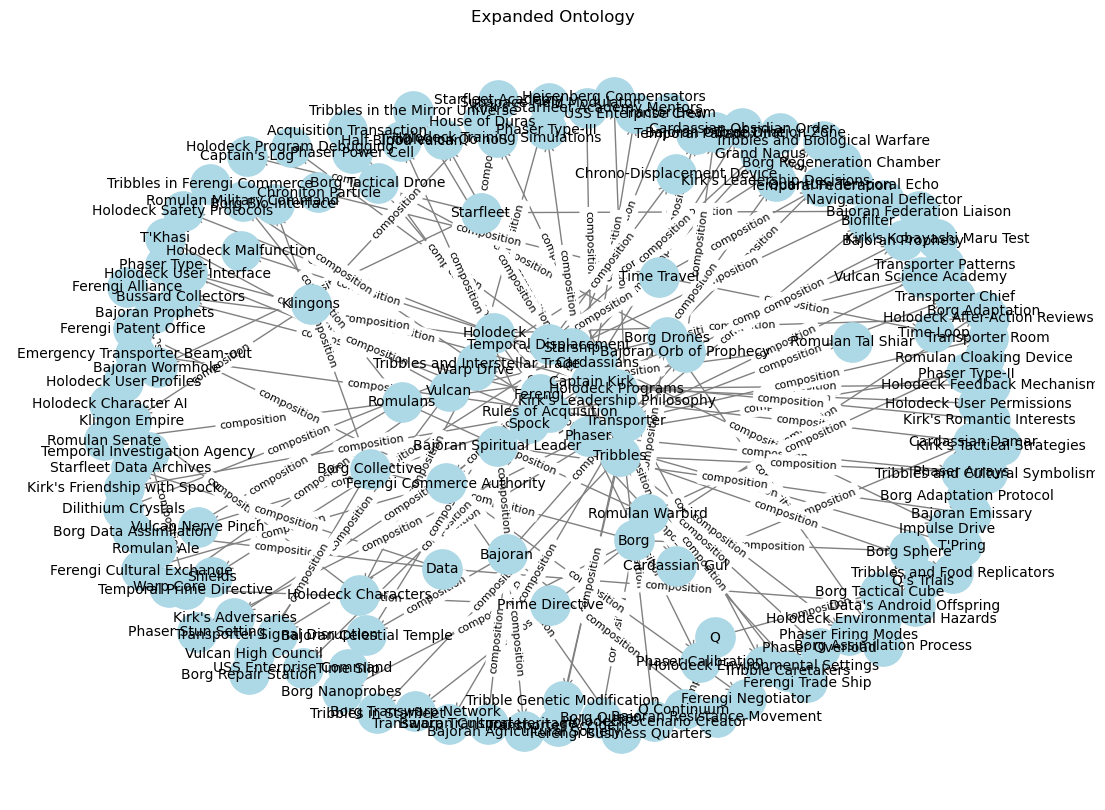

In [21]:
plt.figure(figsize=(14, 10))
# Re-calculate layout with new nodes
pos = nx.spring_layout(expander.ontology, seed=42, k=0.5)

# Draw nodes
nx.draw_networkx_nodes(expander.ontology, pos, node_size=800, node_color='lightblue')
nx.draw_networkx_labels(expander.ontology, pos, font_size=10)

# Draw edges
nx.draw_networkx_edges(expander.ontology, pos, arrowstyle='->', arrowsize=15, edge_color='gray')
edge_labels = {(u, v): d.get('relation', '?') for u, v, d in expander.ontology.edges(data=True)}
nx.draw_networkx_edge_labels(expander.ontology, pos, edge_labels=edge_labels, font_size=8)

plt.title("Expanded Ontology")
plt.axis('off')
plt.show()

In [22]:
#%pip install pyvis

In [23]:
from pyvis.network import Network
import networkx as nx

# 1. Initialize the interactive network
# 'notebook=True' allows it to render in Jupyter
# 'cdn_resources' ensures it loads correctly without external internet dependencies if needed
net = Network(notebook=True, cdn_resources='in_line', height="750px", width="100%", directed=True)

# 2. Convert your NetworkX graph to PyVis
# We iterate manually to add style attributes (color, size) based on node importance
G = expander.ontology

for node in G.nodes():
    # Calculate degree to size nodes (more connections = bigger)
    degree = G.degree(node)
    
    # Base styling
    color = "#97c2fc" # Light blue
    size = 15 + (degree * 2) # Base size 15, grows with connections
    title = f"{node} (Connections: {degree})" # Tooltip text
    
    # Highlight 'Hub' nodes (lots of connections)
    if degree > 4:
        color = "#fb9a99" # Reddish for hubs
    
    net.add_node(node, label=node, title=title, color=color, size=size)

for u, v, data in G.edges(data=True):
    relation = data.get('relation', '')
    # Add edge with label (visible) and title (hover)
    net.add_edge(u, v, label=relation, title=relation, arrows='to')

# 3. Physics Options (Crucial for untangling)
# This forces nodes to spread out and stabilizes the layout
net.repulsion(
    node_distance=200,  # Push nodes further apart
    central_gravity=0.2, # Pull them slightly to center
    spring_length=150,
    spring_strength=0.05,
    damping=0.09
)

# 4. Show the graph
# This creates a file 'ontology.html' and displays it in the notebook iframe
net.show("ontology.html")

ontology.html
